In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import pickle, os, warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs', exist_ok=True)

In [2]:
df = pd.read_csv('../data/smart_system_anomaly_dataset__1_.csv')
print('Shape:', df.shape)
print('\nLabel distribution:')
print(df['label'].value_counts())

Shape: (10000, 14)

Label distribution:
label
Normal               7948
Anomaly_DoS           997
Anomaly_Injection     563
Anomaly_Spoofing      492
Name: count, dtype: int64


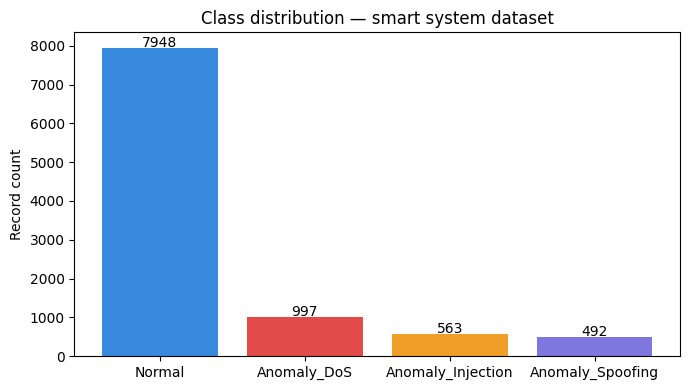

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['label'].value_counts()
colors = ['#378ADD', '#E24B4A', '#EF9F27', '#7F77DD']
ax.bar(counts.index, counts.values, color=colors, edgecolor='none')
ax.set_title('Class distribution — smart system dataset')
ax.set_ylabel('Record count')
for i, (label, val) in enumerate(counts.items()):
    ax.text(i, val + 30, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150)
plt.show()

In [4]:
NUM_COLS = ['cpu_usage', 'memory_usage', 'network_in_kb', 'network_out_kb',
            'packet_rate', 'avg_response_time_ms', 'service_access_count',
            'failed_auth_attempts', 'is_encrypted', 'geo_location_variation']

normal  = df[df['label'] == 'Normal']
anomaly = df[df['label'] != 'Normal']

print(f"\n{'Feature':<32} {'p-value':>9} {'Cohen d':>9} {'Separable?':>12}")
print('-' * 68)
stat_rows = []
for col in NUM_COLS:
    _, p = stats.ttest_ind(normal[col], anomaly[col])
    pooled = np.sqrt((normal[col].std()**2 + anomaly[col].std()**2) / 2) + 1e-8
    d = abs(normal[col].mean() - anomaly[col].mean()) / pooled
    sep = 'YES' if p < 0.05 else 'NO — weak'
    print(f'{col:<32} {p:>9.4f} {d:>9.4f} {sep:>12}')
    stat_rows.append({'feature': col, 'p_value': round(p, 4), 'cohens_d': round(d, 4)})

stats_df = pd.DataFrame(stat_rows)
stats_df.to_csv('../outputs/statistical_analysis.csv', index=False)
print('\n>>> All Cohen\'s d < 0.08 — features weakly separate anomalies.')
print('>>> This is your research problem and motivation.')


Feature                            p-value   Cohen d   Separable?
--------------------------------------------------------------------
cpu_usage                           0.5249    0.0157    NO — weak
memory_usage                        0.2925    0.0260    NO — weak
network_in_kb                       0.8012    0.0062    NO — weak
network_out_kb                      0.0644    0.0461    NO — weak
packet_rate                         0.1870    0.0326    NO — weak
avg_response_time_ms                0.7587    0.0076    NO — weak
service_access_count                0.8609    0.0043    NO — weak
failed_auth_attempts                0.6625    0.0108    NO — weak
is_encrypted                        0.6420    0.0115    NO — weak
geo_location_variation              0.9947    0.0002    NO — weak

>>> All Cohen's d < 0.08 — features weakly separate anomalies.
>>> This is your research problem and motivation.


In [5]:
def engineer_features(df):
    df = df.copy()
    le = LabelEncoder()
    df['device_type_enc']     = le.fit_transform(df['device_type'])
    df['auth_rate']           = df['failed_auth_attempts'] / (df['service_access_count'] + 1)
    df['network_asymmetry']   = (df['network_in_kb'] - df['network_out_kb']).abs()
    df['traffic_density']     = df['packet_rate'] / (df['network_in_kb'] + 1)
    df['cpu_mem_stress']      = df['cpu_usage'] * df['memory_usage'] / 100
    df['response_per_packet'] = df['avg_response_time_ms'] / (df['packet_rate'] + 1)
    return df

df = engineer_features(df)
print('Features after engineering:', df.shape[1])

FEATURES = NUM_COLS + ['device_type_enc', 'auth_rate', 'network_asymmetry',
                        'traffic_density', 'cpu_mem_stress', 'response_per_packet']

Features after engineering: 20


In [6]:
df['label_bin'] = (df['label'] != 'Normal').astype(int)

df_normal  = df[df['label'] == 'Normal'].reset_index(drop=True)
df_anomaly = df[df['label'] != 'Normal'].reset_index(drop=True)

X_norm_train, X_norm_test = train_test_split(
    df_normal[FEATURES], test_size=0.2, random_state=42)

X_anom_test = df_anomaly[FEATURES]

X_test_raw = pd.concat([X_norm_test, X_anom_test], ignore_index=True)
y_test_raw = pd.concat([
    pd.Series(np.zeros(len(X_norm_test), dtype=int)),
    df_anomaly['label_bin'].reset_index(drop=True)
], ignore_index=True)

perm = np.random.permutation(len(X_test_raw))
X_test_raw = X_test_raw.iloc[perm].reset_index(drop=True)
y_test_raw = y_test_raw.iloc[perm].reset_index(drop=True)

In [7]:
scaler = StandardScaler()
X_train_normal = pd.DataFrame(
    scaler.fit_transform(X_norm_train), columns=FEATURES)
X_test = pd.DataFrame(
    scaler.transform(X_test_raw), columns=FEATURES)
y_test = y_test_raw.values

print(f'\nTrain (Normal only): {X_train_normal.shape}')
print(f'Test  (mixed):       {X_test.shape}')
print(f'Anomaly rate in test: {y_test.mean():.2%}')


Train (Normal only): (6358, 16)
Test  (mixed):       (3642, 16)
Anomaly rate in test: 56.34%


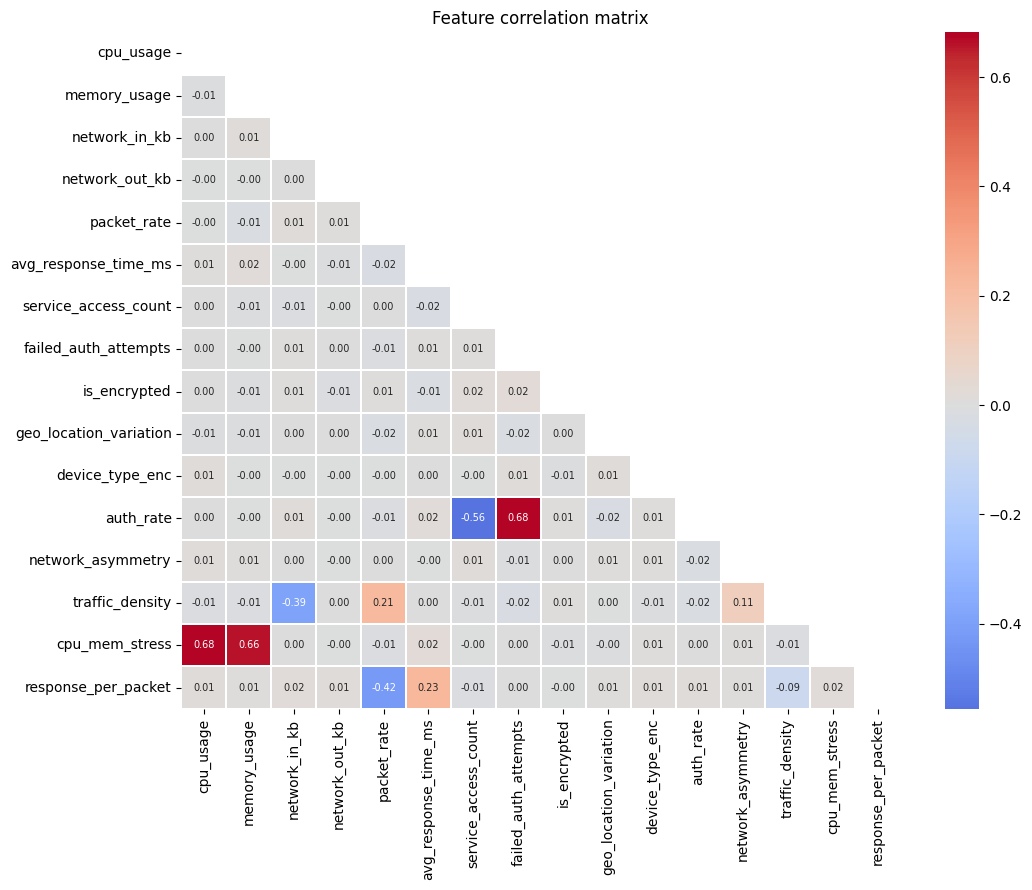

In [8]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = pd.concat([X_train_normal, X_test]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()

In [9]:
with open('../preprocessed_data.pkl', 'wb') as f:
    pickle.dump({
        'X_train_normal': X_train_normal,
        'X_test':         X_test,
        'y_test':         y_test,
        'X_anom_real':    pd.DataFrame(
            scaler.transform(X_anom_test), columns=FEATURES),
        'scaler':         scaler,
        'FEATURES':       FEATURES,
        'df_orig_path':   '../data/smart_system_anomaly_dataset__1_.csv'
    }, f)
print('Saved: ../preprocessed_data.pkl')
print('Notebook 1 complete. Run notebook 2 next.')

Saved: ../preprocessed_data.pkl
Notebook 1 complete. Run notebook 2 next.
